# Generate dataset with GW data

Imports, include the project root in the Python path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal as _lal

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%reload_ext autoreload
%autoreload 2

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd:", Path.cwd())
print("sys.path:", sys.path[:5])

PROJECT_ROOT: /home/victor/gw/cbc_pe
cwd: /home/victor/gw/cbc_pe/notebooks
sys.path: ['/home/victor/gw/cbc_pe', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '']


In [2]:
from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.sampling import ParameterSampler
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector
from src.noise import NoiseModel
from src.injection import SignalInjector
from src.processing import SignalProcessor
from src.labels import LabelTransformer
from src.dataset import DatasetBuilder

Define the simulation configuration for the signals. 
And the processing configuration for the data.

#### Para sistemas cuya duración en banda excede la ventana de análisis, el dataset no contiene la inspiral completa. Se conserva la porción final de la señal dentro de una ventana fija de 4 s, garantizando que al menos el último segundo antes de la coalescencia esté presente. El SNR y el reescalado de distancia se calculan sobre la señal efectivamente usada para la inyección.

In [3]:
config = SimulationConfig(
    sampling_frequency = 4096.0,  # Hz
    duration = 4.0,  # s
    low_frequency_cutoff = 30.0,  # Hz
    waveform_approximant ="SEOBNRv4_opt",
    target_network_snr_range = (10.0, 25.0),
    snr_relative_tolerance = 0.05,
)

signal_processor_dict = {
    "apply_whitening": True, 
    "apply_lowpass": True, 
    "apply_highpass": True, 
    "apply_standardization": True, 
}

Once the config is set up, we can generate the dataset with the DatasetBuilder class.

In [6]:
rng = np.random.default_rng(seed=13) # set random seed for reproducibility

n_samples = 5000

builder = DatasetBuilder.from_config(
        config,
        detector_names=["H1", "L1", "V1"],
        signal_processor_kwargs=signal_processor_dict,
        rng=rng)

batch = builder.build_dataset(
    num_samples=n_samples,
    max_attempts=6000,
)




Built sample 10 of 5000 --> 0.2% completed (attempts=10, failed=0)
Built sample 20 of 5000 --> 0.4% completed (attempts=20, failed=0)
Built sample 30 of 5000 --> 0.6% completed (attempts=30, failed=0)
Built sample 40 of 5000 --> 0.8% completed (attempts=40, failed=0)
Built sample 50 of 5000 --> 1.0% completed (attempts=50, failed=0)
Built sample 60 of 5000 --> 1.2% completed (attempts=60, failed=0)
Built sample 70 of 5000 --> 1.4% completed (attempts=70, failed=0)
Built sample 80 of 5000 --> 1.6% completed (attempts=80, failed=0)
Built sample 90 of 5000 --> 1.8% completed (attempts=90, failed=0)
Built sample 100 of 5000 --> 2.0% completed (attempts=100, failed=0)
Built sample 110 of 5000 --> 2.2% completed (attempts=110, failed=0)
Built sample 120 of 5000 --> 2.4% completed (attempts=120, failed=0)
Built sample 130 of 5000 --> 2.6% completed (attempts=130, failed=0)
Built sample 140 of 5000 --> 2.8% completed (attempts=140, failed=0)
Built sample 150 of 5000 --> 3.0% completed (attempt

Save the dataset to a file.

In [7]:
from src.io import save_dataset_npz

dataset_path = save_dataset_npz(
    batch=batch,
    output_dir=PROJECT_ROOT / "data" / "raw",
    file_name="cbc_dataset_5000.npz",
    detector_names=builder.detector_names,
    overwrite=False,
    ask_before_overwrite=True,
)

Saved dataset to '/home/victor/gw/cbc_pe/data/raw/cbc_dataset_5000.npz'.


## Load the dataset
example: dataset_path = Path("/home/victor/gw/cbc_pe/data/cbc_pe/cbc_pe_4096_4s_30hz_10-25SNR.npz")

In [14]:
import numpy as np

data = np.load(dataset_path)

print(data.files)
print(data["X"].shape)
print(data["y"].shape)
print(data["injection_times"].shape)
print(data["network_snrs"].shape)
print(data["detector_names"])

print(data.keys())
X = data["X"]
y = data["y"]
network_snrs = data["network_snrs"]

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)
print("network_snrs:", network_snrs.shape, network_snrs.dtype)

print("Any NaN in X?", np.isnan(X).any())
print("Any NaN in y?", np.isnan(y).any())
print("Any Inf in X?", np.isinf(X).any())
print("Any Inf in y?", np.isinf(y).any())

['X', 'y', 'injection_times', 'network_snrs', 'detector_names']
(5000, 3, 16384)
(5000, 3)
(5000,)
(5000,)
['H1' 'L1' 'V1']
KeysView(NpzFile '/home/victor/gw/cbc_pe/data/raw/cbc_dataset_5000.npz' with keys: X, y, injection_times, network_snrs, detector_names)
X: (5000, 3, 16384) float32
y: (5000, 3) float32
network_snrs: (5000,) float64
Any NaN in X? False
Any NaN in y? False
Any Inf in X? False
Any Inf in y? False


Checking if the output ranges are correct

In [10]:
label_names = ["chirp_mass", "total_mass", "chi_eff"]

for j, name in enumerate(label_names):
    print(
        f"{name}: "
        f"min={y[:, j].min():.4f}, "
        f"max={y[:, j].max():.4f}, "
        f"mean={y[:, j].mean():.4f}, "
        f"std={y[:, j].std():.4f}"
    )

print(
    f"network_snr: "
    f"min={network_snrs.min():.4f}, "
    f"max={network_snrs.max():.4f}, "
    f"mean={network_snrs.mean():.4f}, "
    f"std={network_snrs.std():.4f}"
)

chirp_mass: min=5.8941, max=77.9759, mean=37.4702, std=16.4803
total_mass: min=13.5959, max=179.1419, mean=95.0202, std=34.7217
chi_eff: min=-0.9904, max=0.9821, mean=0.0074, std=0.4445
network_snr: min=10.0016, max=24.9904, mean=16.9504, std=4.3553


Make histograms of the SNRs of dataset

Text(0.5, 1.0, 'Histogram of the SNR values')

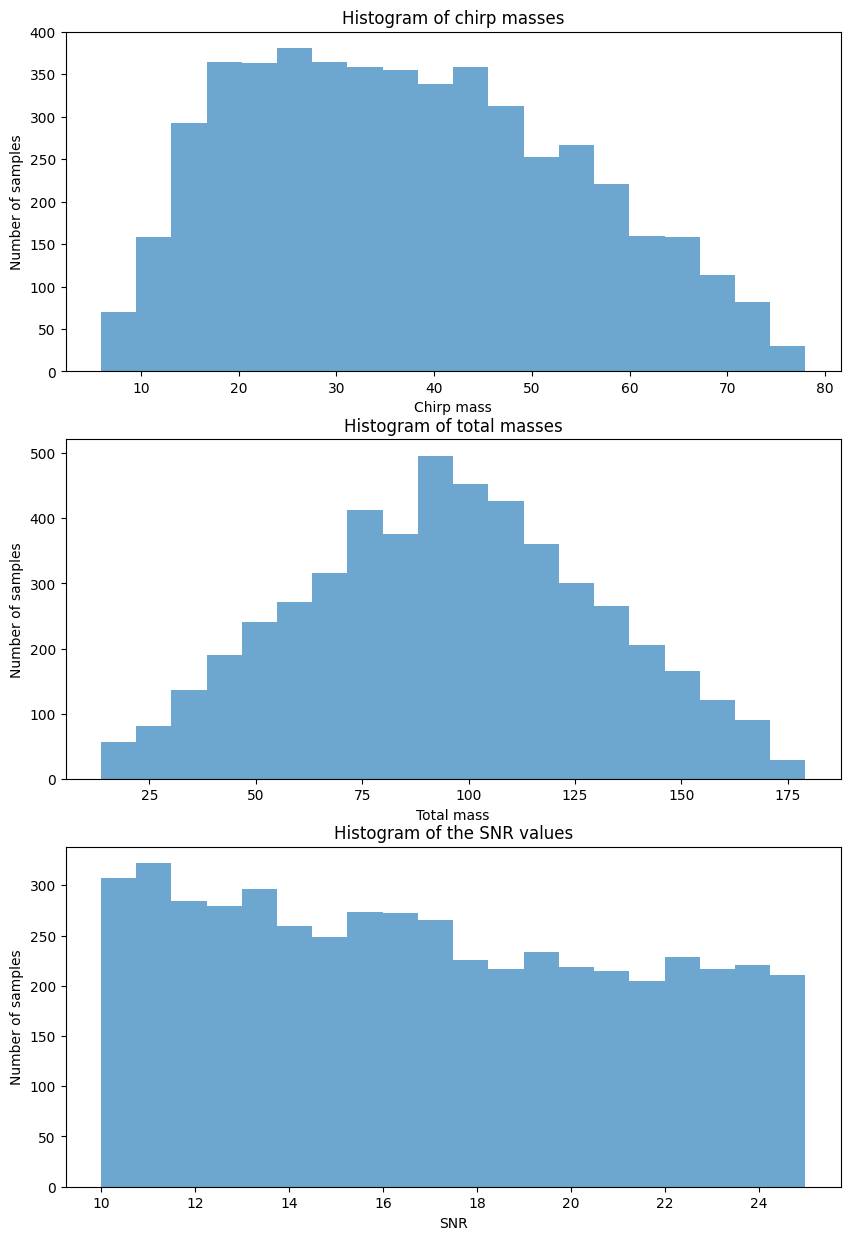

In [49]:
# Histogram of the dataset for the SNR values

plt.figure(figsize=(10, 15))


plt.subplot(3, 1, 1)
plt.hist(y[:, 0], bins=20, histtype="bar", alpha=0.65, rwidth=1) 
plt.xlabel("Chirp mass")
plt.ylabel("Number of samples")
plt.title("Histogram of chirp masses")

plt.subplot(3, 1, 2)
plt.hist(y[:, 1], bins=20, histtype="bar", alpha=0.65, rwidth=1) 
plt.xlabel("Total mass")
plt.ylabel("Number of samples")
plt.title("Histogram of total masses")

plt.subplot(3, 1, 3)
plt.hist(network_snrs, bins=20, histtype="bar", alpha=0.65, rwidth=1) 
plt.xlabel("SNR")
plt.ylabel("Number of samples")
plt.title("Histogram of the SNR values")


